# Requirement 1 - improved version

Same environment, clairvoyant, and budget-blind UCB1 as the baseline version. Only the budgeted learner changes, in three ways:

1. I directly estimate the winning probability p(win) of each bid, from which I obtain expected reward (v-b)p and expected cost b*p;
2. the confidence interval for p(win) uses the KL bound rather than Hoeffding;
3. a bid is playable only if the remaining budget can pay for it.

KL-UCB was not covered in the labs: the reason is in the README, while the ablation at the end compares KL and Hoeffding with everything else unchanged.

## Model

Identical to the baseline version: bids on a grid, uniform competitors, first-price auction, P(win) = b^3.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats

# instance parameters
n_advertisers = 3
n_users = 5000          # T
B = 125                 # total budget
my_valuation = 0.6
rho = B / n_users
n_trials = 10

available_bids = np.round(np.linspace(0.0, 1.0, 11), 10)
good_bids = available_bids[available_bids <= my_valuation + 1e-12]  # bid > v dominati in first-price


class Auction:
    def __init__(self, *args, **kwargs):
        pass

    def get_winners(self, bids):
        pass

    def get_payments_per_click(self, winners, bids):
        pass

    def round(self, bids):
        winners = self.get_winners(bids)
        payments_per_click = self.get_payments_per_click(winners, bids)
        return winners, payments_per_click


class FirstPriceAuction(Auction):
    def __init__(self, qs):
        self.qs = qs
        self.n_adv = len(self.qs)

    def get_winners(self, bids):
        public_values = self.qs * bids
        public_ranking = np.argsort(public_values)
        winner = public_ranking[-1]
        return winner

    def get_payments_per_click(self, winners, bids):
        payment = bids[winners]
        return payment


def generate_competing_bids(T, n_epochs, seed=12345):
    # same market sequences for all agents
    np.random.seed(seed)
    return np.random.uniform(0.0, 1.0, size=(n_epochs, n_advertisers, T))


def true_expected_curves(bids=good_bids, valuation=my_valuation, k=n_advertisers):
    win_probabilities = stats.beta.cdf(bids, k, 1)  # maximum of k uniform variables
    expected_utilities = (valuation - bids) * win_probabilities
    expected_payments = bids * win_probabilities
    return expected_utilities, expected_payments, win_probabilities


def compute_clairvoyant(available_bids, my_valuation, rho, win_probabilities):
    # stochastic-clairvoyant LP: bid distribution with average cost <= rho
    c = -(my_valuation - available_bids) * win_probabilities
    A_ub = [available_bids * win_probabilities]
    b_ub = [rho]
    A_eq = [np.ones(len(available_bids))]
    b_eq = [1]
    res = optimize.linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=(0, 1))
    gamma = np.clip(res.x, 0, None)
    gamma = gamma / gamma.sum()
    return gamma, -res.fun, np.sum(available_bids * gamma * win_probabilities)


class UCB1BudgetBlindAgent:
    """UCB1 over bids; the budget does not enter the score."""

    def __init__(self, bids_set, valuation, budget, T, range=1):
        self.bids_set = bids_set
        self.K = len(bids_set)
        self.valuation = valuation
        self.budget = budget
        self.T = T
        self.range = range
        self.a_t = None
        self.avg_f = np.zeros(self.K)
        self.N_pulls = np.zeros(self.K)
        self.t = 0
        self.last_distribution = np.eye(self.K)[0]

    def pull_arm(self):
        if self.budget < 1:          # stop when the budget is exhausted
            self.a_t = 0
            self.last_distribution = np.eye(self.K)[0]
            return 0
        if self.t < self.K:          # un giro di esplorazione iniziale
            self.a_t = self.t
        else:
            f_ucbs = self.avg_f + self.range * np.sqrt(2 * np.log(self.T) / self.N_pulls)
            self.a_t = int(np.argmax(f_ucbs))
        self.last_distribution = np.eye(self.K)[self.a_t]
        return self.a_t

    def update(self, win_t, f_t, c_t):
        self.N_pulls[self.a_t] += 1
        self.avg_f[self.a_t] += (f_t - self.avg_f[self.a_t]) / self.N_pulls[self.a_t]
        self.budget -= c_t
        self.t += 1


In [41]:
KL_ITERS = 15  # iterazioni di bisezione per invertire il bound KL

def bernoulli_kl(p, q):
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps); q = np.clip(q, eps, 1 - eps)
    return p * np.log(p / q) + (1 - p) * np.log((1 - p) / (1 - q))


def kl_confidence_bounds(p_hat, n_obs, t, n_iter=KL_ITERS):
    # KL confidence interval for p(win); unplayed bids remain in [0, 1]
    p_hat = np.asarray(p_hat, float); n_obs = np.asarray(n_obs, float)
    beta = np.log(max(t, 2))
    observed = n_obs > 0
    # lower bound
    lo = np.zeros_like(p_hat); hi = p_hat.copy()
    for _ in range(n_iter):
        mid = (lo + hi) / 2
        ok = n_obs * bernoulli_kl(p_hat, mid) <= beta
        hi = np.where(ok & observed, mid, hi)
        lo = np.where((~ok) & observed, mid, lo)
    lower = np.where(observed, hi, 0.0)
    # upper bound
    lo = p_hat.copy(); hi = np.ones_like(p_hat)
    for _ in range(n_iter):
        mid = (lo + hi) / 2
        ok = n_obs * bernoulli_kl(p_hat, mid) <= beta
        lo = np.where(ok & observed, mid, lo)
        hi = np.where((~ok) & observed, mid, hi)
    upper = np.where(observed, lo, 1.0)
    return lower, upper


def hoeffding_confidence_bounds(p_hat, n_obs, t):
    # Hoeffding bound on the same p(win), used in the ablation
    p_hat = np.asarray(p_hat, float); n_obs = np.asarray(n_obs, float)
    rad = np.sqrt(np.log(max(t, 2)) / (2 * np.maximum(n_obs, 1)))
    lower = np.where(n_obs > 0, np.clip(p_hat - rad, 0, 1), 0.0)
    upper = np.where(n_obs > 0, np.clip(p_hat + rad, 0, 1), 1.0)
    return lower, upper


def solve_lp_distribution(reward, cost, rho_t, feasible):
    # same LP as the baseline, with zero bound on unaffordable bids
    K = len(reward)
    bounds = [(0.0, 1.0) if feasible[a] else (0.0, 0.0) for a in range(K)]
    res = optimize.linprog(c=-np.asarray(reward), A_ub=[np.asarray(cost)], b_ub=[rho_t],
                           A_eq=[np.ones(K)], b_eq=[1.0], bounds=bounds, method="highs")
    if (not res.success) or res.x is None:
        gamma = np.zeros(K); gamma[0] = 1.0   # fallback sul bid nullo
        return gamma
    gamma = np.clip(res.x, 0, None)
    return gamma / gamma.sum()


class BudgetedLearner:
    """Learner budgeted: stima p(win), bound KL (o Hoeffding), LP con rho = B/T."""

    def __init__(self, bids_set, valuation, budget, T, use_kl=True):
        self.bids_set = bids_set; self.K = len(bids_set)
        self.valuation = valuation; self.budget = budget; self.T = T
        self.rho = budget / T
        self.use_kl = use_kl
        self.a_t = None; self.N_pulls = np.zeros(self.K); self.n_wins = np.zeros(self.K)
        self.t = 0; self.last_distribution = np.eye(self.K)[0]

    def pull_arm(self):
        feasible = self.bids_set <= self.budget + 1e-12   # only play bids that can be paid
        if not np.any(feasible):
            self.a_t = 0; self.last_distribution = np.eye(self.K)[0]; return 0
        untried = np.where((self.N_pulls == 0) & feasible)[0]
        if len(untried) > 0:
            self.a_t = int(untried[0]); self.last_distribution = np.eye(self.K)[self.a_t]; return self.a_t
        # obtain the bid’s expected reward and cost from p(win)
        p_hat = np.divide(self.n_wins, self.N_pulls, out=np.zeros(self.K), where=self.N_pulls > 0)
        if self.use_kl:
            p_lcb, p_ucb = kl_confidence_bounds(p_hat, self.N_pulls, self.t + 1)
        else:
            p_lcb, p_ucb = hoeffding_confidence_bounds(p_hat, self.N_pulls, self.t + 1)
        optimistic_reward = (self.valuation - self.bids_set) * p_ucb
        optimistic_cost = self.bids_set * p_lcb
        zero_bid = np.isclose(self.bids_set, 0.0)
        optimistic_reward[zero_bid] = 0.0; optimistic_cost[zero_bid] = 0.0
        gamma_t = solve_lp_distribution(optimistic_reward, optimistic_cost, self.rho, feasible)
        self.a_t = int(np.random.choice(self.K, p=gamma_t)); self.last_distribution = gamma_t
        return self.a_t

    def update(self, win_t, f_t, c_t):
        self.N_pulls[self.a_t] += 1
        self.n_wins[self.a_t] += win_t
        self.budget -= c_t; self.t += 1


In [42]:
def run_one_trial(agent, competing_bids, opt_per_round, bids_set=good_bids):
    T = competing_bids.shape[1]
    auction = FirstPriceAuction(np.ones(n_advertisers + 1))
    utilities = np.zeros(T)
    costs = np.zeros(T)
    chosen_arms = np.zeros(T, dtype=int)

    for u in range(T):
        arm = agent.pull_arm()
        my_bid = bids_set[arm]
        bids = np.append(my_bid, competing_bids[:, u].ravel())
        winners, payment_per_click = auction.round(bids=bids)
        my_win = int(winners == 0)
        f_t, c_t = (my_valuation - payment_per_click) * my_win, payment_per_click * my_win
        agent.update(my_win, f_t, c_t)

        chosen_arms[u] = arm
        utilities[u] = f_t
        costs[u] = c_t

    return {"cum_reward": np.cumsum(utilities), "cum_cost": np.cumsum(costs),
            "regret": np.cumsum(opt_per_round - utilities), "chosen_arms": chosen_arms,
            "n_pulls": agent.N_pulls.copy(), "final_budget": agent.budget}


def stack_metric(runs, key):
    return np.vstack([r[key] for r in runs])

def regret_matrix(runs):
    return stack_metric(runs, "regret")

def pseudo_regret_matrix(runs):
    # regret on the true means of selected bids, without single-auction noise
    return np.vstack([np.cumsum(clairvoyant_reward - true_reward[run["chosen_arms"]]) for run in runs])

def arm_frequency_table(runs):
    counts = np.vstack([r["n_pulls"] for r in runs])
    freq = counts.mean(axis=0) / counts.sum(axis=1).mean()
    return pd.DataFrame({"bid": good_bids, "mean_frequency": freq})

def summarize_runs(label, runs):
    regrets = regret_matrix(runs); pseudo = pseudo_regret_matrix(runs)
    T = regrets.shape[1]
    realized_reward = np.array([run["cum_reward"][-1] for run in runs])
    spend = np.array([run["cum_cost"][-1] for run in runs])
    return {"agent": label, "mean_final_regret": regrets[:, -1].mean(),
            "sem_final_regret": regrets[:, -1].std(ddof=1) / np.sqrt(len(runs)),
            "regret_over_T": regrets[:, -1].mean() / T,
            "mean_final_pseudo_regret": pseudo[:, -1].mean(),
            "mean_realized_reward": realized_reward.mean(), "mean_spend": spend.mean(),
            "reward_over_clairvoyant": realized_reward.mean() / (clairvoyant_reward * T)}

def regret_checkpoint_table(label, runs, checkpoints=(0.25, 0.50, 0.75, 1.00)):
    regrets = regret_matrix(runs).mean(axis=0); T = regrets.shape[0]; rows = []
    for q in checkpoints:
        idx = int(q * T) - 1
        rows.append({"agent": label, "fraction_of_horizon": q, "t": idx + 1,
                     "average_regret_Rt_over_t": regrets[idx] / (idx + 1)})
    return pd.DataFrame(rows)


## Clairvoyant

Same benchmark as the baseline version: LP with average constraint rho = B/T.

In [43]:
true_reward, true_cost, win_probabilities = true_expected_curves(good_bids, my_valuation, n_advertisers)
gamma_clairvoyant, clairvoyant_reward, clairvoyant_cost = compute_clairvoyant(
    good_bids, my_valuation, rho, win_probabilities
)

pd.DataFrame({
    "bid": good_bids,
    "P(win)": win_probabilities,
    "E[reward]": true_reward,
    "E[cost]": true_cost,
    "clairvoyant_gamma": gamma_clairvoyant,
})

,bid,P(win),E[reward],E[cost],clairvoyant_gamma
0,0.0,0.000,0.0000,0.0000,0.000000
1,0.1,0.001,0.0005,0.0001,0.000000
2,0.2,0.008,0.0032,0.0016,0.000000
3,0.3,0.027,0.0081,0.0081,0.034286
4,0.4,0.064,0.0128,0.0256,0.965714
5,0.5,0.125,0.0125,0.0625,0.000000
6,0.6,0.216,0.0000,0.1296,0.000000


## Experiment

Same market sequences and protocol as the baseline version.

In [44]:
# 10 paired runs: same market sequences for both agents
all_competing_bids = generate_competing_bids(n_users, n_trials, seed=20260517)

ucb_runs, budgeted_runs = [], []
for epoch in range(n_trials):
    blind_agent = UCB1BudgetBlindAgent(good_bids, my_valuation, B, n_users, range=my_valuation)
    budgeted_agent = BudgetedLearner(good_bids, my_valuation, B, n_users, use_kl=True)
    ucb_runs.append(run_one_trial(blind_agent, all_competing_bids[epoch], clairvoyant_reward))
    np.random.seed(20_000 + epoch)
    budgeted_runs.append(run_one_trial(budgeted_agent, all_competing_bids[epoch], clairvoyant_reward))

summary_table = pd.DataFrame([
    summarize_runs("UCB1 budget-blind", ucb_runs),
    summarize_runs("Budgeted KL-UCB", budgeted_runs),
])
summary_table

,agent,mean_final_regret,sem_final_regret,regret_over_T,mean_final_pseudo_regret,mean_realized_reward,mean_spend,reward_over_clairvoyant
0,UCB1 budget-blind,40.184286,0.49339,0.008037,40.773786,23.01,124.29,0.364115
1,Budgeted KL-UCB,11.374286,1.50265,0.002275,12.261426,51.82,123.20,0.820011


In [45]:
checkpoint_table = pd.concat([
    regret_checkpoint_table("UCB1 budget-blind", ucb_runs),
    regret_checkpoint_table("Budgeted KL-UCB", budgeted_runs),
], ignore_index=True)
checkpoint_table

,agent,fraction_of_horizon,t,average_regret_Rt_over_t
0,UCB1 budget-blind,0.25,1250,0.006847
1,UCB1 budget-blind,0.50,2500,0.006507
2,UCB1 budget-blind,0.75,3750,0.006663
3,UCB1 budget-blind,1.00,5000,0.008037
4,Budgeted KL-UCB,0.25,1250,0.003591
5,Budgeted KL-UCB,0.50,2500,0.002039
6,Budgeted KL-UCB,0.75,3750,0.001975
7,Budgeted KL-UCB,1.00,5000,0.002275


In [46]:
budgeted_frequency = arm_frequency_table(budgeted_runs)
budgeted_frequency["clairvoyant_gamma"] = gamma_clairvoyant
budgeted_frequency

,bid,mean_frequency,clairvoyant_gamma
0,0.0,0.02696,0.000000
1,0.1,0.05888,0.000000
2,0.2,0.07412,0.000000
3,0.3,0.16650,0.034286
4,0.4,0.51516,0.965714
5,0.5,0.15818,0.000000
6,0.6,0.00020,0.000000


## Plots

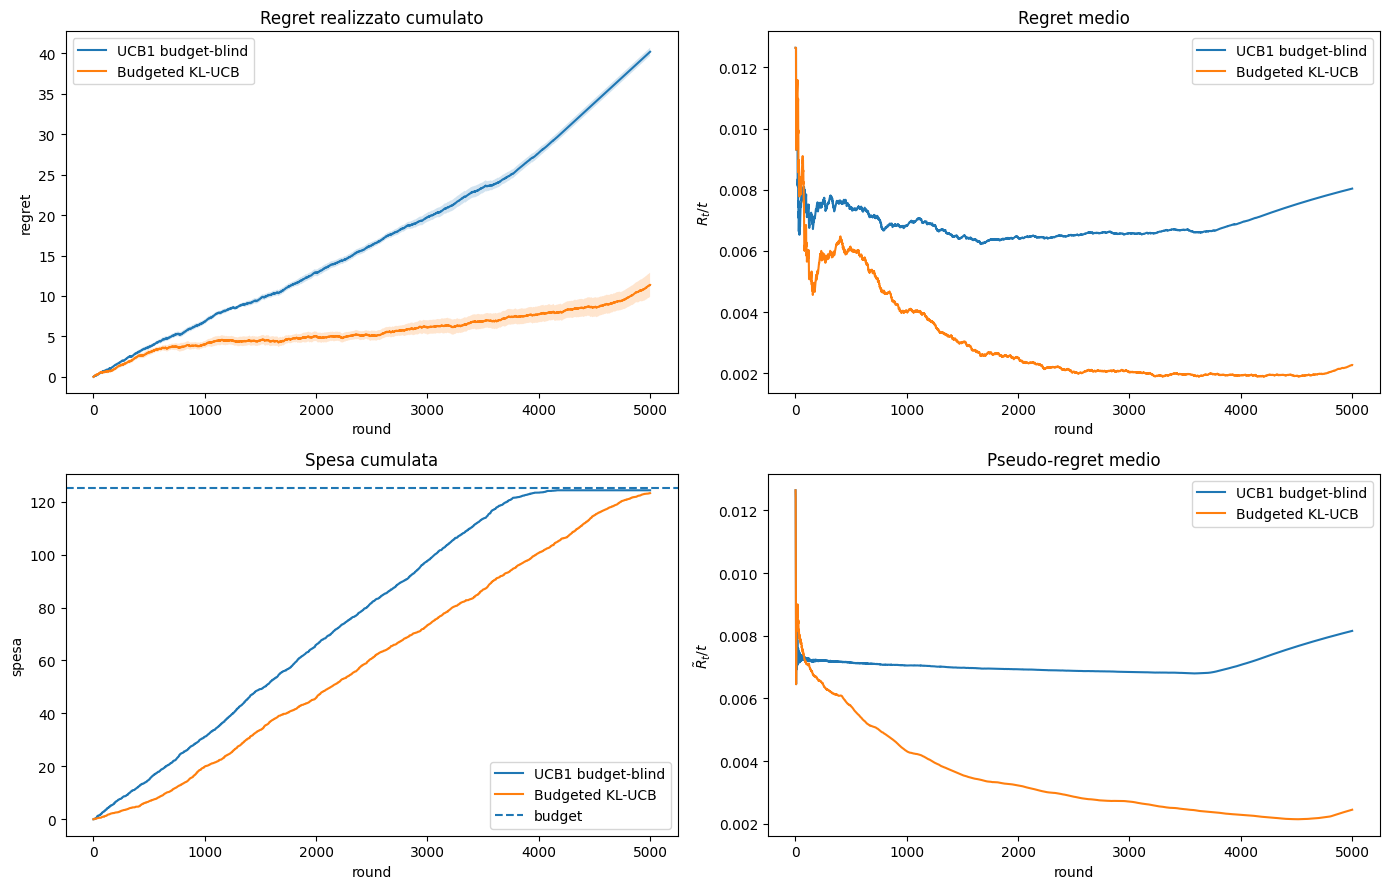

In [47]:
ucb_regret = regret_matrix(ucb_runs)
budgeted_regret = regret_matrix(budgeted_runs)
ucb_pseudo = pseudo_regret_matrix(ucb_runs)
budgeted_pseudo = pseudo_regret_matrix(budgeted_runs)
x = np.arange(1, n_users + 1)

def mean_sem(m):
    return m.mean(axis=0), m.std(axis=0, ddof=1) / np.sqrt(m.shape[0])

ucb_mean, ucb_sem = mean_sem(ucb_regret)
bud_mean, bud_sem = mean_sem(budgeted_regret)
ucb_pmean, _ = mean_sem(ucb_pseudo)
bud_pmean, _ = mean_sem(budgeted_pseudo)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(x, ucb_mean, label="UCB1 budget-blind")
axes[0, 0].fill_between(x, ucb_mean - ucb_sem, ucb_mean + ucb_sem, alpha=0.2)
axes[0, 0].plot(x, bud_mean, label="Budgeted KL-UCB")
axes[0, 0].fill_between(x, bud_mean - bud_sem, bud_mean + bud_sem, alpha=0.2)
axes[0, 0].set_title("Regret realizzato cumulato")
axes[0, 0].set_xlabel("round"); axes[0, 0].set_ylabel("regret"); axes[0, 0].legend()

axes[0, 1].plot(x, ucb_mean / x, label="UCB1 budget-blind")
axes[0, 1].plot(x, bud_mean / x, label="Budgeted KL-UCB")
axes[0, 1].set_title("Regret medio")
axes[0, 1].set_xlabel("round"); axes[0, 1].set_ylabel(r"$R_t/t$"); axes[0, 1].legend()

ucb_cost = stack_metric(ucb_runs, "cum_cost")
bud_cost = stack_metric(budgeted_runs, "cum_cost")
axes[1, 0].plot(x, ucb_cost.mean(axis=0), label="UCB1 budget-blind")
axes[1, 0].plot(x, bud_cost.mean(axis=0), label="Budgeted KL-UCB")
axes[1, 0].axhline(B, linestyle="--", label="budget")
axes[1, 0].set_title("Cumulative expenditure")
axes[1, 0].set_xlabel("round"); axes[1, 0].set_ylabel("expenditure"); axes[1, 0].legend()

axes[1, 1].plot(x, ucb_pmean / x, label="UCB1 budget-blind")
axes[1, 1].plot(x, bud_pmean / x, label="Budgeted KL-UCB")
axes[1, 1].set_title("Pseudo-regret medio")
axes[1, 1].set_xlabel("round"); axes[1, 1].set_ylabel(r"$\tilde R_t/t$"); axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Regret as T varies

In [48]:
# same rho, different horizons
scaling_rows = []
for T_s, seed_s in [(1000, 910000), (3000, 912000), (5000, 914000)]:
    bids_s = generate_competing_bids(T_s, n_trials, seed=seed_s)
    runs_s = []
    for epoch in range(n_trials):
        learner_s = BudgetedLearner(good_bids, my_valuation, rho * T_s, T_s, use_kl=True)
        np.random.seed(20_000 + epoch)
        runs_s.append(run_one_trial(learner_s, bids_s[epoch], clairvoyant_reward))
    reg = regret_matrix(runs_s)
    pse = pseudo_regret_matrix(runs_s)
    scaling_rows.append({
        "T": T_s, "budget": rho * T_s,
        "mean_final_regret": reg[:, -1].mean(),
        "sem_final_regret": reg[:, -1].std(ddof=1) / np.sqrt(n_trials),
        "regret_over_T": reg[:, -1].mean() / T_s,
        "pseudo_regret_over_T": pse[:, -1].mean() / T_s,
        "mean_spend": np.mean([r["cum_cost"][-1] for r in runs_s]),
    })

scaling_table = pd.DataFrame(scaling_rows)
scaling_table

,T,budget,mean_final_regret,sem_final_regret,regret_over_T,pseudo_regret_over_T,mean_spend
0,1000,25.0,3.948857,0.690161,0.003949,0.004264,19.45
1,3000,75.0,7.476571,1.323564,0.002492,0.002933,67.72
2,5000,125.0,16.484286,1.084174,0.003297,0.003463,120.63


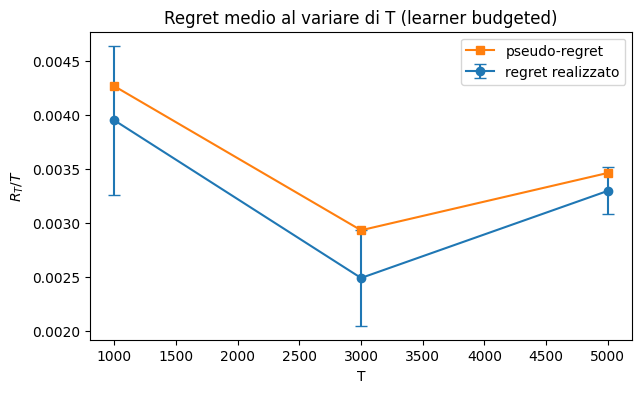

In [49]:
plt.figure(figsize=(7, 4))
plt.errorbar(scaling_table["T"], scaling_table["regret_over_T"],
             yerr=scaling_table["sem_final_regret"] / scaling_table["T"], marker="o", capsize=4, label="regret realizzato")
plt.plot(scaling_table["T"], scaling_table["pseudo_regret_over_T"], marker="s", label="pseudo-regret")
plt.title("Regret medio al variare di T (learner budgeted)")
plt.xlabel("T"); plt.ylabel(r"$R_T/T$"); plt.legend()
plt.show()

## Ablation: KL vs Hoeffding

Same learner, same estimate of p(win), same LP: only the confidence bound changes.

In [50]:
# same learner; only the p(win) bound changes. KL runs are from the main experiment
hoeff_runs = []
for epoch in range(n_trials):
    hoeff_agent = BudgetedLearner(good_bids, my_valuation, B, n_users, use_kl=False)
    np.random.seed(20_000 + epoch)
    hoeff_runs.append(run_one_trial(hoeff_agent, all_competing_bids[epoch], clairvoyant_reward))

def ablation_row(label, runs):
    reg = regret_matrix(runs)
    reward = np.array([r["cum_reward"][-1] for r in runs])
    spend = np.array([r["cum_cost"][-1] for r in runs])
    return {"config": label, "mean_final_regret": reg[:, -1].mean(),
            "mean_reward": reward.mean(), "mean_spend": spend.mean(),
            "reward_over_clairvoyant": reward.mean() / (clairvoyant_reward * n_users)}

ablation_table = pd.DataFrame([ablation_row("KL-UCB", budgeted_runs),
                               ablation_row("Hoeffding", hoeff_runs)])
ablation_table

,config,mean_final_regret,mean_reward,mean_spend,reward_over_clairvoyant
0,KL-UCB,11.374286,51.82,123.20,0.820011
1,Hoeffding,35.724286,27.47,45.55,0.434691


## Note on the results

The KL-UCB budgeted learner ends with mean regret of about 11.4, compared with about 40.2 for the budget-blind learner; it reaches about 82% of the clairvoyant reward and spends 123 of 125 while spreading expenditure over the entire horizon. Mean regret per round decreases along the horizon (from 0.0036 to about 0.0023) and remains at these levels as T changes.

The ablation explains the source of the gain: with Hoeffding, regret rises to about 35.7 and expenditure drops to 45 of 125. With few observations, Hoeffding intervals saturate (p_ucb close to 1 for every bid), so optimistic reward (v-b)*p_ucb ranks bids in reverse order, favoring low bids that almost never win. The KL bound tightens much faster near 0 and distinguishes bids with small winning probabilities, which are the relevant ones here.